<a href="https://colab.research.google.com/github/zapneel1/0/blob/main/Swapneel_Layek_Colrows_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loan Recovery Rate Prediction

This notebook develops a machine learning model to predict the recovery rate of defaulted loans using the provided ARC dataset.

The workflow includes:
- Data loading and exploration
- Feature engineering
- Leakage prevention
- Model training using CatBoost Regressor
- Model evaluation
- Feature importance analysis
- Final prediction generation

In [43]:
!pip -q install catboost

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from catboost import CatBoostRegressor

In [45]:
train = pd.read_csv("/content/arc_loan_recovery_train.csv")
test = pd.read_csv("/content/arc_loan_recovery_test.csv")

print("Train:", train.shape)
print("Test :", test.shape)

train.head()

Train: (7000, 32)
Test : (2000, 28)


,loan_id,loan_amount,term_months,grade,sub_grade,int_rate,emp_length_years,home_ownership,annual_income,verification_status,...,collateral_value,total_pymnt_before_default,outstanding_principal,days_past_due_at_default,months_in_recovery,recovery_status,payment_plan_status,recoveries,collection_recovery_fee,recovery_rate
0,ARC100186,10900.0,60,E,E2,21.98,1.0,RENT,95500.0,Source Verified,...,NaN,4473.43,6426.57,72,23,Closed,No_Plan,800.75,103.09,0.1246
1,ARC106212,17100.0,36,B,B5,10.87,10.0,MORTGAGE,36700.0,Not Verified,...,NaN,8634.50,8465.50,75,8,Closed,Active,4810.94,563.55,0.5683
2,ARC101863,17400.0,36,G,G3,28.82,10.0,RENT,50100.0,Source Verified,...,NaN,5100.21,12299.79,32,32,Closed,Broken,3624.75,366.76,0.2947
3,ARC100317,6700.0,36,A,A1,10.62,9.0,MORTGAGE,20400.0,Not Verified,...,NaN,1525.02,5174.98,108,30,Closed,Active,2387.22,305.99,0.4613
4,ARC106446,24200.0,60,B,B4,10.44,NaN,RENT,45200.0,Source Verified,...,13800.0,4413.43,19786.57,292,20,Closed,Active,9606.38,594.96,0.4855


## Exploratory Data Analysis

The dataset contains both numerical and categorical loan characteristics along with recovery process information.

In [46]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loan_id                     7000 non-null   object 
 1   loan_amount                 7000 non-null   float64
 2   term_months                 7000 non-null   int64  
 3   grade                       7000 non-null   object 
 4   sub_grade                   7000 non-null   object 
 5   int_rate                    7000 non-null   float64
 6   emp_length_years            6654 non-null   float64
 7   home_ownership              7000 non-null   object 
 8   annual_income               6506 non-null   float64
 9   verification_status         7000 non-null   object 
 10  purpose                     7000 non-null   object 
 11  dti                         6795 non-null   float64
 12  fico_range_low              7000 non-null   int64  
 13  fico_range_high             7000 

In [47]:
train.isnull().sum().sort_values(ascending=False)

,0
collateral_value,5444
annual_income,494
emp_length_years,346
revol_util,279
dti,205
sub_grade,0
grade,0
loan_id,0
home_ownership,0
int_rate,0


## Feature Engineering

Additional features were created to capture credit quality and financial burden:

- Average FICO score
- FICO score spread
- Loan-to-income ratio
- Revolving balance to income ratio

In [48]:
def engineer_features(df):

    df = df.copy()

    df["fico_avg"] = (
        df["fico_range_low"] +
        df["fico_range_high"]
    ) / 2

    df["fico_spread"] = (
        df["fico_range_high"] -
        df["fico_range_low"]
    )

    df["loan_income_ratio"] = (
        df["loan_amount"] /
        (df["annual_income"] + 1)
    )

    df["revol_income_ratio"] = (
        df["revol_bal"] /
        (df["annual_income"] + 1)
    )

    return df


train_fe = engineer_features(train)
test_fe = engineer_features(test)

## Preventing Target Leakage

The following variables were excluded:

- loan_id (identifier)
- recoveries
- collection_recovery_fee
- recovery_rate (target)
- payment_plan_status (not available in test data)

This ensures only features available during inference are used.

In [49]:
drop_cols = [
    "loan_id",
    "recoveries",
    "collection_recovery_fee",
    "recovery_rate",
    "payment_plan_status"
]

X = train_fe.drop(columns=drop_cols)

y = train_fe["recovery_rate"]

X_test = test_fe.drop(columns=["loan_id"])

cat_features = X.select_dtypes(include="object").columns.tolist()

In [50]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model Training

CatBoost Regressor was selected because it naturally handles categorical features, missing values, and nonlinear relationships while requiring minimal preprocessing.

In [51]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

0:	learn: 0.1888214	test: 0.1908491	best: 0.1908491 (0)	total: 92.6ms	remaining: 1m 32s
100:	learn: 0.1217147	test: 0.1240027	best: 0.1240027 (100)	total: 1.74s	remaining: 15.5s
200:	learn: 0.1153728	test: 0.1197021	best: 0.1197021 (200)	total: 2.86s	remaining: 11.4s
300:	learn: 0.1121856	test: 0.1183939	best: 0.1183939 (300)	total: 4.12s	remaining: 9.56s
400:	learn: 0.1094705	test: 0.1179401	best: 0.1179203 (395)	total: 6.07s	remaining: 9.07s
500:	learn: 0.1076505	test: 0.1178946	best: 0.1178588 (483)	total: 7.38s	remaining: 7.35s
600:	learn: 0.1053780	test: 0.1180262	best: 0.1178588 (483)	total: 8.47s	remaining: 5.62s
700:	learn: 0.1032824	test: 0.1179496	best: 0.1178588 (483)	total: 9.58s	remaining: 4.09s
800:	learn: 0.1011363	test: 0.1180337	best: 0.1178588 (483)	total: 10.7s	remaining: 2.66s
900:	learn: 0.0991738	test: 0.1181439	best: 0.1178588 (483)	total: 13.2s	remaining: 1.45s
999:	learn: 0.0970990	test: 0.1182896	best: 0.1178588 (483)	total: 14.3s	remaining: 0us

bestTest = 0.

CatBoostRegressor(depth=6, eval_metric='RMSE', iterations=1000, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [52]:
pred = model.predict(X_valid)

print("MAE :", mean_absolute_error(y_valid, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, pred)))
print("R2  :", r2_score(y_valid, pred))

MAE : 0.09503424038725025
RMSE: 0.11785876797364757
R2  : 0.6290802574048957


In [53]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.get_feature_importance()
}).sort_values(
    "Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
26,recovery_status,33.956227
24,days_past_due_at_default,10.817334
10,dti,8.330007
27,fico_avg,7.697900
11,fico_range_low,6.931458
12,fico_range_high,5.368374
13,delinq_2yrs,3.701612
20,collateral_flag,3.263875
21,collateral_value,2.944495
5,emp_length_years,2.897568


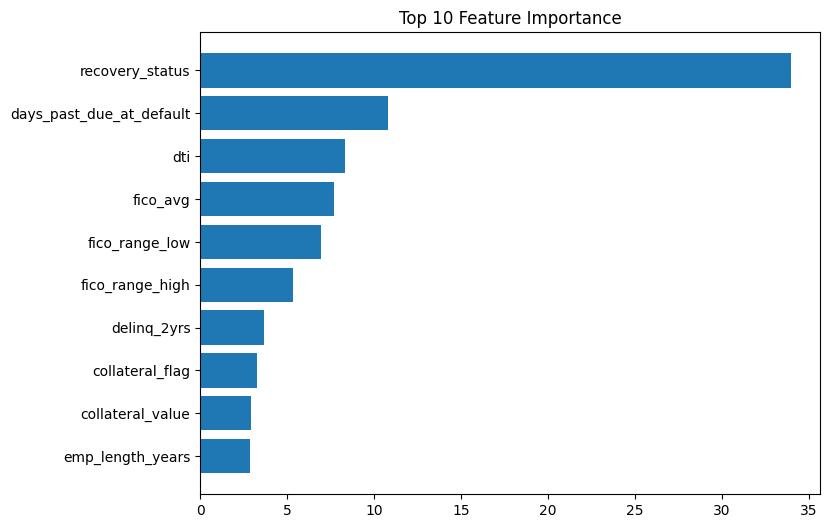

In [54]:
plt.figure(figsize=(8,6))

plt.barh(
    importance.head(10)["Feature"][::-1],
    importance.head(10)["Importance"][::-1]
)

plt.title("Top 10 Feature Importance")

plt.show()

## Final Model Training

After validation, the same configuration is retrained on the complete training dataset before generating predictions for the unseen test set.

In [55]:
final_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=False
)

final_model.fit(
    X,
    y,
    cat_features=cat_features
)

CatBoostRegressor(depth=6, eval_metric='RMSE', iterations=1000, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=False)

In [57]:
test_pred = final_model.predict(X_test)

submission = pd.DataFrame({
    "loan_id": test["loan_id"],
    "predicted_recovery_rate": test_pred.clip(0, 1)
})

submission.to_csv("predictions.csv", index=False)

submission.head()

,loan_id,predicted_recovery_rate
0,ARC104645,0.579607
1,ARC104205,0.509226
2,ARC102896,0.129392
3,ARC106617,0.211063
4,ARC105889,0.173683
